In [1]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path so `from tools...` imports work from any notebook subfolder.
_p = Path.cwd().resolve()
for _parent in [_p, *_p.parents]:
    if (_parent / 'tools' / 'search_tools.py').exists():
        sys.path.insert(0, str(_parent))
        break
del _p, _parent


In [2]:
%%capture --no-stderr
# %pip install "autogen-agentchat~=0.2.3"

# In Your OAI_CONFIG_LIST file, you must have two configs,
# one with:           "response_format": { "type": "text" }
# and the other with: "response_format": { "type": "json_object" }


[
    {"model": "gpt-4o-mini", "sk-REDACTED": "key go here", "response_format": {"type": "text"}},
]

In [3]:
import autogen
import os
from autogen.agentchat import UserProxyAgent
from autogen.agentchat.assistant_agent import AssistantAgent
from autogen.agentchat.groupchat import GroupChat
os.environ["SERPER_API_KEY"] = "1edefaec0732d11db50b993ba60539510cc55334"
from tools.search_tools import SearchTools




In [4]:
from autogen import ConversableAgent
from autogen import register_function

import os
import json
import requests

def search_internet(query: str) -> str:
        """Useful to search the internet
        about a a given topic and return relevant results"""
        print("Searching the internet...")
        top_result_to_return = 5
        url = "https://google.serper.dev/search"
        payload = json.dumps(
            {"q": query, "num": top_result_to_return, "tbm": "nws"})
        headers = {
            'X-API-KEY': os.environ['SERPER_API_KEY'],
            'content-type': 'application/json'
        }
        response = requests.request("POST", url, headers=headers, data=payload)
        # check if there is an organic key
        if 'organic' not in response.json():
            return "Sorry, I couldn't find anything about that, there could be an error with you serper api key."
        else:
            results = response.json()['organic']
            string = []
            print("Results:", results[:top_result_to_return])
            for result in results[:top_result_to_return]:
                try:
                    # Attempt to extract the date
                    date = result.get('date', 'Date not available')
                    string.append('\n'.join([
                        f"Title: {result['title']}",
                        f"Link: {result['link']}",
                        f"Date: {date}",  # Include the date in the output
                        f"Snippet: {result['snippet']}",
                        "\n-----------------"
                    ]))
                except KeyError:
                    next

            return '\n'.join(string)

        



In [5]:
from autogen import ConversableAgent, register_function
import os

# Define the function that reads the entire novel
def read_novel() -> str:
    """
    Reads the entire content of the 'Flatland' novel stored in a text file.

    Returns:
    - str: The full content of the novel.
    """
    file_path = "flatland.txt"  # Ensure this file is in the same directory

    if not os.path.exists(file_path):
        return "Error: The novel file 'flatland.txt' was not found in the directory."

    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            return file.read()
    except Exception as e:
        return f"An error occurred while reading the file: {e}"

In [15]:
import asyncio
import autogen
import os
import httpx
from typing import Optional, List, Dict, Tuple, Union
import random  # noqa E402

import matplotlib.pyplot as plt  # noqa E402
import networkx as nx  # noqa E402

import autogen  # noqa E402
from autogen.agentchat.conversable_agent import ConversableAgent  # noqa E402
from autogen.agentchat.assistant_agent import AssistantAgent  # noqa E402
from autogen.agentchat.groupchat import GroupChat  # noqa E402
from autogen.graph_utils import visualize_speaker_transitions_dict 

# Set your OpenAI API key
os.environ["OPENAI_API_KEY"] = "sk-REDACTED"

# Define a custom HTTP client
class MyHttpClient(httpx.Client):
    def __deepcopy__(self, memo):
        return self

# Configure the language model
llm_config = {
    "config_list": [
        {"model": "gpt-4o", "api_key": os.environ.get("OPENAI_API_KEY")},
    ]
}


class MemoryAgent(ConversableAgent):
    def __init__(self, name, system_message, llm_config):
        super().__init__(name=name, system_message=system_message, llm_config=llm_config)
        self.memory = []

    def receive(self, message, sender, request_reply=None, silent=False):
        print(f"[{self.name}] Received message from {sender.name}: {message}")
        if isinstance(message, dict):
            # Check for tool-related keys
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                # Store the received message in memory if it's not tool-related
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message received and not stored in memory: {message}")
        else:
            print(f"Warning: Received a message without expected structure: {message}")
        # Call the parent class's receive method to handle the message
        super().receive(message, sender, request_reply, silent)

    def send(self, message, recipient, request_reply=None, silent=False):
        print(f"[{self.name}] Sending message to {recipient.name}: {message}")
        if isinstance(message, dict):
            # Check for tool-related keys
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                # Store the agent's response in memory if it's not tool-related
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message sent and not stored in memory: {message}")
        else:
            print(f"Warning: Sending a message without expected structure: {message}")
        # Call the parent class's send method to send the message
        super().send(message, recipient, request_reply, silent)

    def generate_response(self, messages):
        # Limit to the last 10 messages from memory
        recent_memory = self.memory[-10:]
        # Prepare the conversation context
        conversation = [{"role": "system", "content": self.system_message}] + recent_memory + messages + "choose who do you want to speak next"
        # Generate a response using the language model
        response = self.llm.generate(conversation)
        # Store the response in memory
        self.memory.append({"role": "assistant", "content": response})
        return response


def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False


user_proxy = autogen.UserProxyAgent(
    name="User_proxy",
    system_message="A human admin who terminates the chat when the leader agent sends a message with 'TERMINATE' mentioned it it",
    code_execution_config=False,
    human_input_mode="NEVER",
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    llm_config=llm_config,
)

# Warehouse layout as a grid with item locations
warehouse_layout = """
Layout (5x5 grid):
S = Shelf, A = Aisle, B = Blocked, C = Charging Station, T = Trolley

[ S: Item1, Item2 ][ A ][ S: Item3, Item4 ][ T ][ A ]
[ A ][ B ][ A ][ A ][ C ]
[ S: Item5, Item6 ][ A ][ S: Item7 ][ B ][ A ]
[ C ][ A ][ T ][ A ][ S: Item8, Item9 ]
[ A ][ S: Item10 ][ A ][ A ][ A ]
"""

# Detailed orders
orders = [
    {"order_id": 1, "priority": "urgent", "items": ["Item1", "Item5"], "destination": "Dispatch Zone 1"},
    {"order_id": 2, "priority": "express", "items": ["Item3"], "destination": "Dispatch Zone 2"},
    {"order_id": 3, "priority": "standard", "items": ["Item8", "Item9"], "destination": "Dispatch Zone 3"},
    {"order_id": 4, "priority": "urgent", "items": ["Item7"], "destination": "Dispatch Zone 1"},
]

# Include orders and layout in Leader's instructions
Leader = MemoryAgent(
    name="Leader",
    system_message=(
        "You are Leader.\n"
        "Task: Coordinate Picker, Packer, Inventory_Manager and Transporter to fulfill warehouse operations:\n"
        "- Resolve blocked aisles, missing trolleys, and battery constraints.\n"
        "- Ensure priority orders (urgent > express > standard) are completed first.\n"
        "- **Always decide who the next speaker will be**"
        "Finalize a stable plan and say 'TERMINATE'."
    ),
    llm_config=llm_config,
)

# Agent A (Picker Robot)
Picker = MemoryAgent(
    name="Picker",
    system_message=(
        "You are Picker:\n"
        "- Task: Pick items from shelves for orders.\n"
        "- Follow the layout to identify item locations:\n"
        "- **Always decide who the next speaker will be**"
        "- Handle blocked aisles and battery constraints (40%).\n"
        "- Notify Leader of obstacles or issues."
    ),
    llm_config=llm_config,
)

# Agent B (Sorter/Packer Robot)
Packer = MemoryAgent(
    name="Packer",
    system_message=(
        "You are Packer:\n"
        "- Task: Sort and pack items for orders.\n"
        "- Ensure urgent orders are packed first.\n"
        "- Follow the layout to identify item locations:\n"
        "- **Always decide who the next speaker will be**"
        "- Follow the leader"
    ),
    llm_config=llm_config,
)

# Agent C (Transporter Robot)
Transporter = MemoryAgent(
    name="Transporter",
    system_message=(
        "You are Transporter:\n"
        "- Task: Deliver packed orders to their destinations.\n"
        "- Follow the layout to identify item locations:\n"
        "- **Always decide who the next speaker will be**"
        "- Follow the leader"
        "- Manage trolleys, prioritize urgent deliveries, and recharge if battery is low."
    ),
    llm_config=llm_config,
)

# Agent D (Inventory Manager Robot)
Inventory_Manager = MemoryAgent(
    name="Inventory_Manager",
    system_message=(
        "You are Inventory Manager:\n"
        "- Task: Track stock levels and alert Leader if items are unavailable.\n"
        "- Suggest substitutes for out-of-stock items.\n"
        "- Follow the layout to identify item locations:\n"
        "- **Always decide who the next speaker will be**"
        "- Follow the leader"
    ),
    llm_config=llm_config,
)

Agent5 = ConversableAgent(
    name="Tool_executor",
    system_message=( 
        "You are responsible for executing the tools"
    ),
    # llm_config={"config_list": [{"model": "gpt-4o-mini", "api_key": os.environ.get("OPENAI_API_KEY")}]}
    llm_config=llm_config,
)

# Initial message with layout and orders



In [16]:
import requests
import json

def query_ollama(prompt, model="qwen2.5:72b"):
    url = "https://j7xh0h8qgd777e-11434.proxy.runpod.net/api/generate"  # Ensure correct endpoint
    payload = {"model": model, "prompt": prompt}
    
    try:
        response = requests.post(url, json=payload)
        response.raise_for_status()  # Check for HTTP errors
        
        # Process response line by line
        result = ""
        for line in response.text.splitlines():
            try:
                line_data = json.loads(line)
                result += line_data.get("response", "")
                if line_data.get("done", False):
                    break
            except json.JSONDecodeError:
                continue  # Ignore lines that aren't valid JSON
                
        return result.strip()  # Return the concatenated response
    except requests.exceptions.RequestException as e:
        return {"error": "Request failed", "details": str(e)}

In [17]:
# # Add a global or class-level variable to track the first call
# is_first_call = True  # This flag tracks if the function is being called for the first time

# def custom_speaker_selection_func(last_speaker, groupchat):
#     global is_first_call

#     # If this is the first call, return the leader agent
#     if is_first_call:
#         is_first_call = False  # Reset the flag after the first call
#         print("First call detected. Setting speaker to Leader agent.")
#         for agent in groupchat.agents:
#             if agent.name == "Leader":  # Replace "Agent3" with the actual leader agent's name
#                 return agent
#         print("Error: Leader agent not found in the agents list.")
#         return None  # Handle the case where the leader agent is not found

#     # Access the last message in the group chat
#     last_message = groupchat.messages[-1]
#     print(f"Last message content: {last_message}")

#     # Prepare the input for the LLM
#     prompt = (
#     "You are a conversation coordinator. Based on the last message, decide which agent should speak next out of the following Summarizer_Agent_1, Summarizer_Agent_2, Summarizer_Agent_3 and Leader. "
#     "ONLY RESPOND WITH THE NAME OF THE AGENT AND NOTHING ELSE. NO OTHER CHARACTERS SHOULD BE THERE IN YOUR MESSAGE.\n\n"
#     f"The last message is: {last_message.get('content', '')}"
#     )

#     # Analyze the message using the local LLM
#     response = query_ollama(prompt)
#     print(f"LLM response: {response}")

#     # Extract the relevant text from the response dictionary
#     next_speaker_name = response  # Replace 'text' with the correct key

#     # Find the corresponding agent in the group chat
#     for agent in groupchat.agents:
#         if agent.name == next_speaker_name:
#             return agent

#     # If no valid agent is found, return None or a default fallback
#     print(f"No valid agent found for the name: {next_speaker_name}")
#     return None


In [18]:
# Global variables to track the first call and the call count
is_first_call = True  # Tracks if this is the first call
call_count = 0        # Tracks the number of times the function has been called

def custom_speaker_selection_func(last_speaker, groupchat):
    global is_first_call, call_count

    # If this is the first call, return the leader agent
    if is_first_call:
        is_first_call = False  # Reset the flag after the first call
        print("First call detected. Setting speaker to Leader agent.")

        for agent in groupchat.agents:
            if agent.name == "Leader":  # Replace "Leader" with the actual leader agent's name
                return agent
        print("Error: Leader agent not found in the agents list.")
        return None  # Handle the case where the leader agent is not found

    # Increment the call count
    call_count += 1

    # If this is the 7th call, return the leader agent
    if call_count % 7 == 0:
        print(f"7th call detected (call count: {call_count}). Setting speaker to Leader agent.")
        for agent in groupchat.agents:
            if agent.name == "Leader":  # Replace "Leader" with the actual leader agent's name
                return agent
        print("Error: Leader agent not found in the agents list.")
        return None  # Handle the case where the leader agent is not found

    # Access the last message in the group chat
    last_message = groupchat.messages[-1]
    print(f"Last message content: {last_message}")

    # Prepare the input for the LLM
    prompt = (
        "You are a conversation coordinator. Based on the last message, decide which agent should speak next only out of the following Picker, Packer, Transporter, Inventory_Manager and Leader.  **There are no agents with no other names apart from these 5 so only choose one of them**\n"
        "ONLY RESPOND WITH THE NAME OF THE AGENT AND NOTHING ELSE. NO OTHER CHARACTERS SHOULD BE THERE IN YOUR MESSAGE.\n\n"
        f"The last message is: {last_message.get('content', '')}"
    )

    # Analyze the message using the local LLM
    response = query_ollama(prompt)
    print(f"LLM response: {response}")

    # Extract the relevant text from the response dictionary
    next_speaker_name = response.strip()  # Use .strip() to remove any extra spaces or newlines

    # Find the corresponding agent in the group chat
    for agent in groupchat.agents:
        if agent.name == next_speaker_name:
            return agent

    # If no valid agent is found, return None or a default fallback
    print(f"No valid agent found for the name: {next_speaker_name}")
    return None


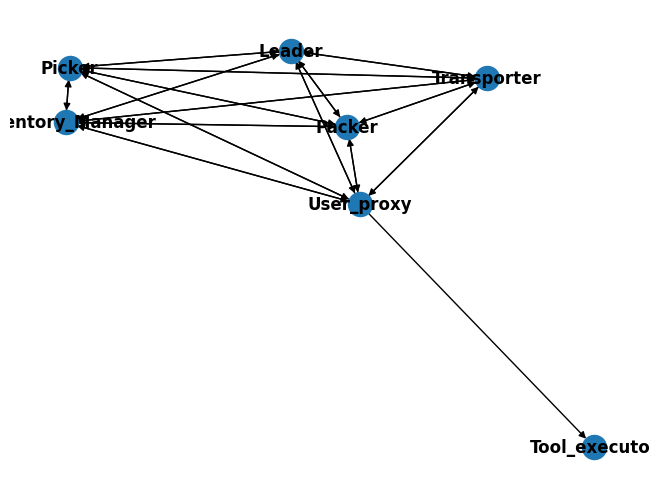

In [19]:
# Define your agents
agents = [Picker, Packer, Inventory_Manager, Transporter, Leader, user_proxy, Agent5]

# Initialize the allowed speaker transitions dictionary
allowed_speaker_transitions_dict = {}

# Set up transitions for each agent
for agent in agents:
    if agent == Agent5:
        # Agent5 cannot send messages to any agent
        allowed_speaker_transitions_dict[agent] = []
    else:
        # Other agents can send messages to all agents except themselves and Agent5
        allowed_speaker_transitions_dict[agent] = [
            other_agent for other_agent in agents
            if other_agent != agent and other_agent != Agent5
        ]

# Allow user_proxy to send messages to Agent5
allowed_speaker_transitions_dict[user_proxy].append(Agent5)

# Visualize the transitions
visualize_speaker_transitions_dict(allowed_speaker_transitions_dict, agents)


In [20]:
def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False


agents.append(user_proxy)

group_chat = GroupChat(
    agents=agents,
    messages=[],
    max_round=100,
    allowed_or_disallowed_speaker_transitions=allowed_speaker_transitions_dict,
    speaker_transitions_type="allowed",
    speaker_selection_method=custom_speaker_selection_func,
)
# Create the manager
manager = autogen.GroupChatManager(
    groupchat=group_chat,
    llm_config=llm_config,
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    code_execution_config=False,
)


In [21]:
# from autogen import register_function


# register_function(
#     read_novel,
#     caller=Agent0,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

# register_function(
#     read_novel,
#     caller=Agent1,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

# register_function(
#     read_novel,
#     caller=Agent2,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

# register_function(
#     read_novel,
#     caller=Agent3,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

# register_function(
#     read_novel,
#     caller=Agent4,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

In [22]:
# chat_result = user_proxy.initiate_chat(Agent0, message="search internet about google. Use production Manager first")

In [23]:
# Prepare the initial message with the novel's text
initial_message = (
    "Leader: A, B, C, D, we face a complex scenario:\n"
    "- Layout reference:\n"
    f"{warehouse_layout}\n"
    "- Orders:\n"
    f"{orders}\n"
    "- Issues: 2 blocked aisles, 1 trolley missing, C's battery is low.\n"
    "Propose your initial solutions to address these issues and fulfill the orders. I will then work towards the final plan"
)



# Initiate the conversation
user_proxy.initiate_chat(manager, message=initial_message)

User_proxy (to chat_manager):

Leader: A, B, C, D, we face a complex scenario:
- Layout reference:

Layout (5x5 grid):
S = Shelf, A = Aisle, B = Blocked, C = Charging Station, T = Trolley

[ S: Item1, Item2 ][ A ][ S: Item3, Item4 ][ T ][ A ]
[ A ][ B ][ A ][ A ][ C ]
[ S: Item5, Item6 ][ A ][ S: Item7 ][ B ][ A ]
[ C ][ A ][ T ][ A ][ S: Item8, Item9 ]
[ A ][ S: Item10 ][ A ][ A ][ A ]

- Orders:
[{'order_id': 1, 'priority': 'urgent', 'items': ['Item1', 'Item5'], 'destination': 'Dispatch Zone 1'}, {'order_id': 2, 'priority': 'express', 'items': ['Item3'], 'destination': 'Dispatch Zone 2'}, {'order_id': 3, 'priority': 'standard', 'items': ['Item8', 'Item9'], 'destination': 'Dispatch Zone 3'}, {'order_id': 4, 'priority': 'urgent', 'items': ['Item7'], 'destination': 'Dispatch Zone 1'}]
- Issues: 2 blocked aisles, 1 trolley missing, C's battery is low.
Propose your initial solutions to address these issues and fulfill the orders. I will then work towards the final plan

------------------

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-REDACTED. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

In [14]:
last_message = group_chat.messages[-1] if group_chat.messages else None
if last_message:
    print("Final Message Content:", last_message['content'])

Final Message Content: ### Action Taken:
- Moved trolley from [1,4] to [2,1].

### Current Layout:
[ S: Item1, Item2 ][ A ][ S: Item3, Item4 ][ T ][ A ]
[ A ][ B ][ A ][ A ][ C ]
[ S: Item5, Item6 ][ A ][ S: Item7 ][ B ][ A ]
[ C ][ A ][ T ][ A ][ S: Item8, Item9 ]
[ A ][ S: Item10 ][ A ][ A ][ A ]

### Next Steps:
- **Picker and Packer (A):** Clear the blocked aisle in row 2.
- **Picker and Packer (B):** Clear the blocked aisle in row 3.

Leader, the trolley has been moved to [2,1]. Picker and Packer (A) and Picker and Packer (B), please proceed with clearing the blocked aisles. 

Next speaker: Picker and Packer (A).


In [15]:
def save_conversation_to_file(groupchat, filename="chat.txt"):
    """
    Save the entire conversation history to a specified file.

    Args:
        groupchat (GroupChat): The GroupChat instance containing the messages.
        filename (str): The name of the file to save the conversation history.
    """
    if not groupchat.messages:
        print("No messages in the group chat to save.")
        return

    # Compile the conversation history
    conversation_history = "\n".join(
        f"{msg['role']}: {msg['content']}" for msg in groupchat.messages
    )

    # Write the conversation history to the file
    with open(filename, "w", encoding="utf-8") as file:
        file.write(conversation_history)

    print(f"Conversation history saved to {filename}")
    
save_conversation_to_file(group_chat, filename="chat.txt")


Conversation history saved to chat.txt


In [16]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# Initialize the Llama 3.1 model
llm = ChatOpenAI(
    model="llama3.1",
    base_url="http://44.221.48.158:11434/v1"
)

def structure_logs_with_local_llm(file_path, initial_message):
    """
    Reads chat logs from a file and generates a structured summary.

    Args:
        file_path (str): Path to the chat log file.
        initial_message (str): The initial task or prompt for context.

    Returns:
        str: The structured summary generated by the LLM.
    """
    # Read the chat logs from the file
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            log_context = file.read()
    except FileNotFoundError:
        return "Error: The specified file was not found."
    except Exception as e:
        return f"An error occurred while reading the file: {e}"

    # Prepare the messages for the LLM
    messages = [
        {
            "role": "system",
            "content": (
                "You are a professional chat summarizer who goes through the entire chat and creates a proper summary based on the '{initial_message}'."
            )
        },
        {
            "role": "user",
            "content": (
                f"Convert the following agent logs into a structured format and into a proper summarized final output "
                f"based on the task '{initial_message}'.\n\nLogs:\n{log_context}"
            )
        }
    ]

    # Generate the structured summary using the LLM
    try:
        response = llm.invoke(messages)
        if isinstance(response, AIMessage):
            structured_summary = response.content
        else:
            structured_summary = "Unexpected response type from the model."
    except Exception as e:
        structured_summary = f"An error occurred during LLM processing: {e}"

    return structured_summary


In [ ]:
# Define the path to your chat log file and the initial task message
file_path = 'chat.txt'
initial_message = 'Design a comprehensive digital marketing course.'

# Generate the structured summary
summary = structure_logs_with_local_llm(file_path, initial_message)

# Output the summary
print(summary)